# SQL Business Analysis

This section explores key business questions using **SQL queries executed in Google BigQuery**.

The objective is to analyze important aspects of the e-commerce platform, including:

* **Revenue Trend Analysis**
* **Delivery Performance Analysis**
* **Customer Retention**
* **Cohort Analysis**

The queries are executed in **Google BigQuery**, and the results are interpreted to derive **business insights that support data-driven decision making**.


## Revenue Trend Analysis

### Business Question

How has total marketplace revenue changed over time?

Understanding revenue trends helps identify whether the platform is growing and how purchasing activity evolves over time.


**SQL QUERY FOR REVENUE TREND ANALYSIS**  
SELECT  
FORMAT_DATE('%Y-%m', order_date) AS month,  
SUM(total_order_value) AS revenue  
FROM master_orders_features  
GROUP BY month  
ORDER BY month

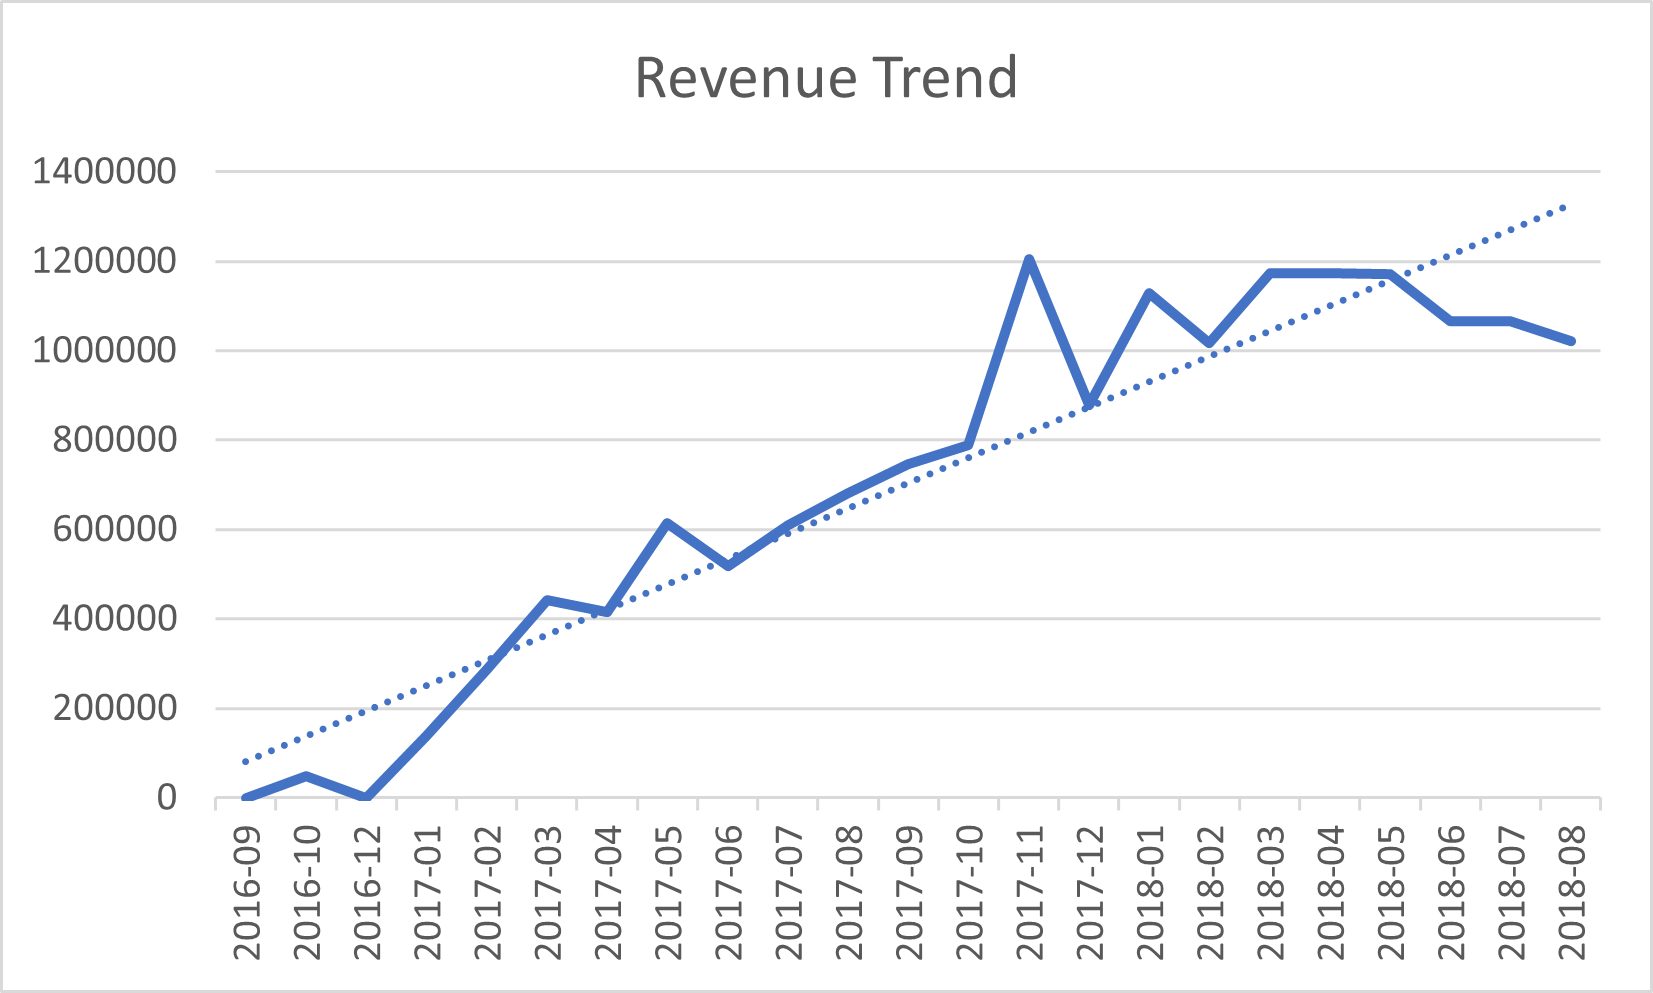

### Key Insight

* Revenue shows a **strong growth trend from early 2017 to 2018**.
* The marketplace experienced **rapid expansion during 2017**, with revenue increasing month by month.
* The **highest revenue occurs around late 2017 and early 2018**, indicating peak platform activity.
* After the peak, revenue stabilizes above **1M BRL per month**, suggesting sustained marketplace demand.


## Delivery Performance Analysis

### Business Question

What proportion of orders are delivered on time versus delayed?

Delivery performance is a key operational metric for e-commerce platforms because delays can significantly affect customer satisfaction and review ratings.


**SQL QUERY FOR DELIVERY PERFORMANCE ANALYSIS**  
SELECT  
delivery_status,  
COUNT(*) AS total_orders  
FROM master_orders_features  
GROUP BY delivery_status  
ORDER BY total_orders DESC

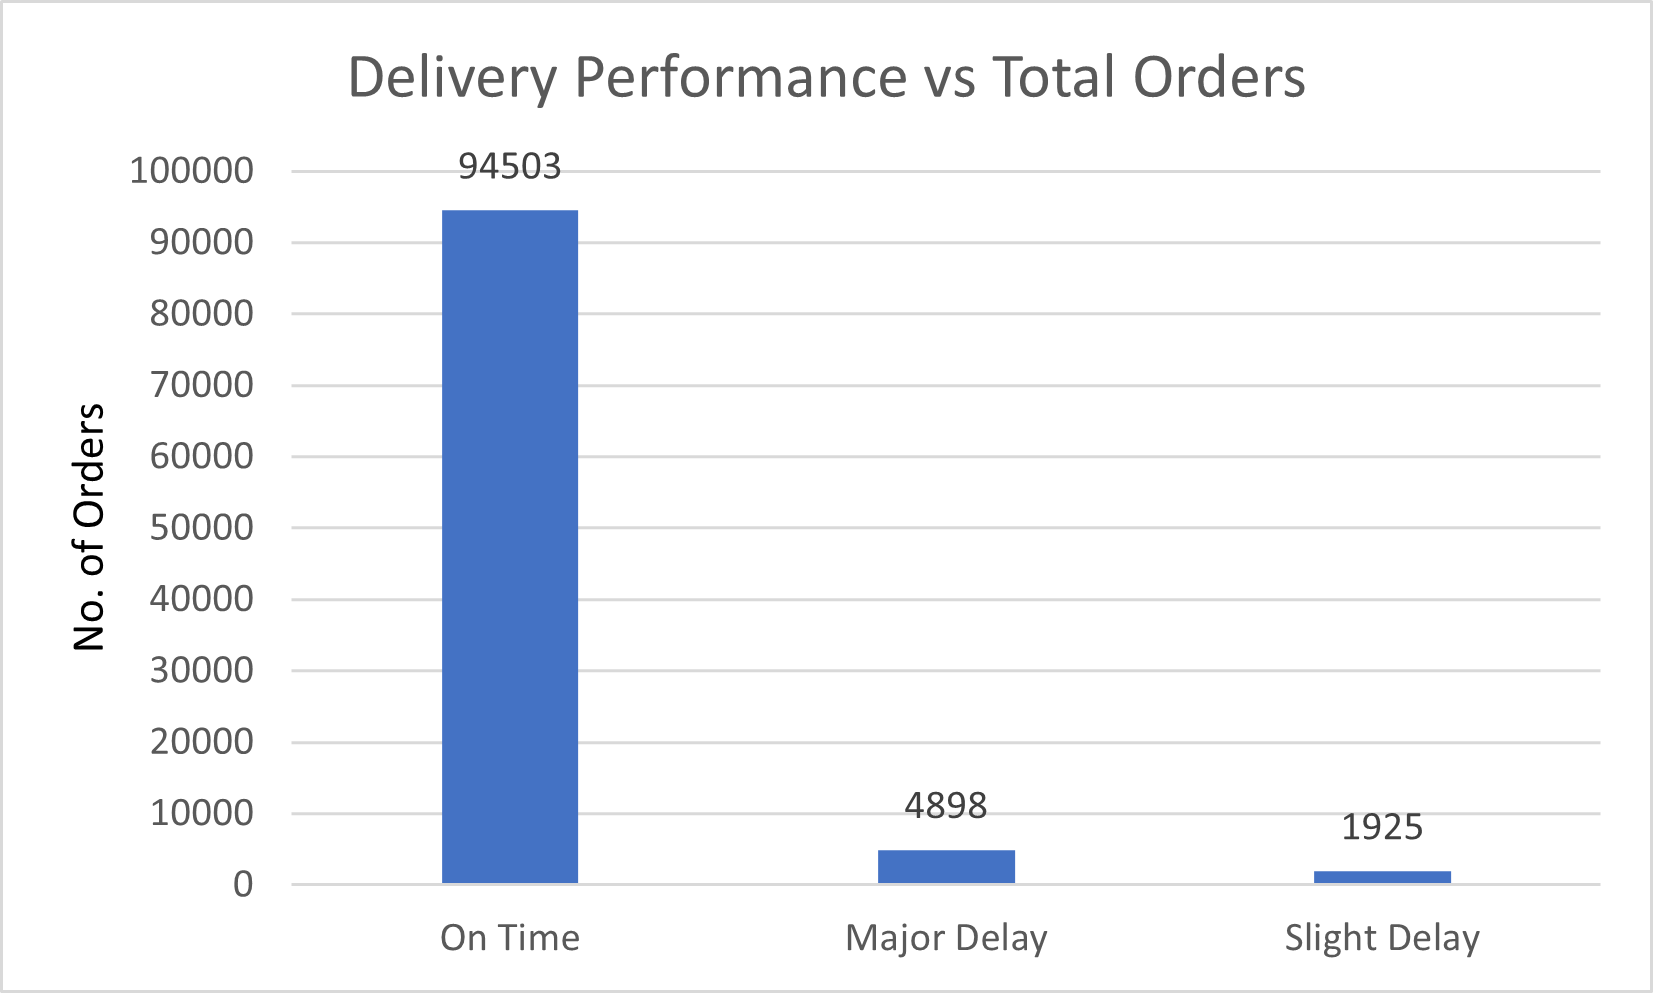

### Key Insight

* The vast majority of orders are **delivered on time (94,503 orders)**, indicating strong overall logistics performance.
* A smaller number of orders experience **major delays (4,898 orders)** and **slight delays (1,925 orders)**.
* Delayed deliveries represent only a **small percentage of total orders**, but they can still significantly affect customer experience.
* Earlier statistical testing showed that **late deliveries reduce review scores substantially**, highlighting the importance of maintaining reliable delivery operations.


## Customer Retention Analysis

### Business Question

Do customers return after their first purchase, or do most customers buy only once?

Customer retention is a critical metric in e-commerce because retaining existing customers is often more cost-effective than acquiring new ones.


**SQL QUERY FOR CUSTOMER RETENTION ANALYSIS**  
SELECT  
CASE  
WHEN order_count = 1 THEN 'One-Time Customer'  
ELSE 'Returning Customer'  
END AS customer_type,  
COUNT(*) AS customers  
FROM (  
SELECT  
customer_id,  
COUNT(order_id) AS order_count  
FROM master_orders_features  
GROUP BY customer_id  
)  
GROUP BY customer_type

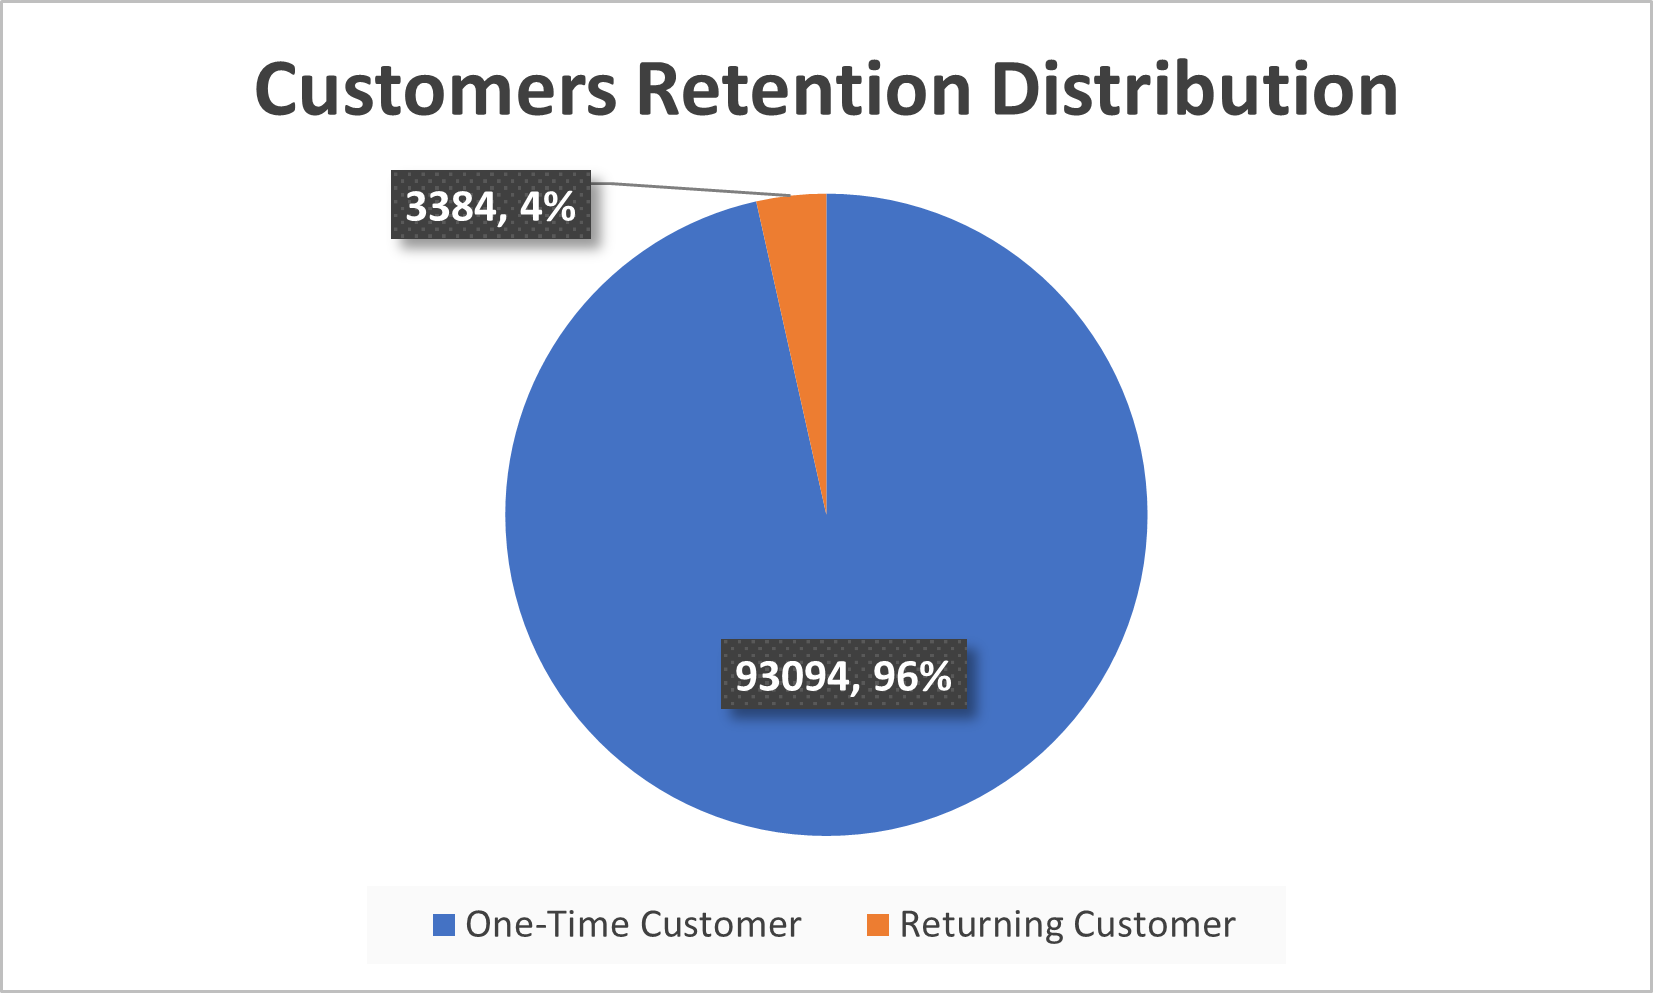

### Key Insight

* The majority of customers are **one-time buyers (93,094 customers)**.
* Only a small portion of customers return to make **additional purchases (3,384 customers)**.
* This indicates that the platform experiences **low customer retention**, with most customers purchasing only once.
* Improving retention through strategies such as **loyalty programs, targeted promotions, or personalized recommendations** could increase repeat purchases and overall customer lifetime value.

## Cohort Analysis

### Business Question

How does customer retention change over time after their first purchase?

Cohort analysis groups customers based on the month of their first purchase and tracks whether they return in later months. This helps understand long-term customer engagement and retention patterns.


**SQL FOR COHORT ANALYSIS**

WITH first_purchase AS (  
SELECT  
customer_id,  
DATE_TRUNC(MIN(order_date), MONTH) AS cohort_month  
FROM master_orders_features  
GROUP BY customer_id  
),  
  
customer_orders AS (  
SELECT  
customer_id,  
DATE_TRUNC(order_date, MONTH) AS order_month  
FROM master_orders_features  
)  
  
SELECT  
cohort_month,  
order_month,  
DATE_DIFF(order_month, cohort_month, MONTH) AS   months_since_first_purchase,  
COUNT(DISTINCT customer_id) AS customers  
FROM customer_orders  
JOIN first_purchase USING(customer_id)  
GROUP BY cohort_month, order_month  
ORDER BY cohort_month, order_month  

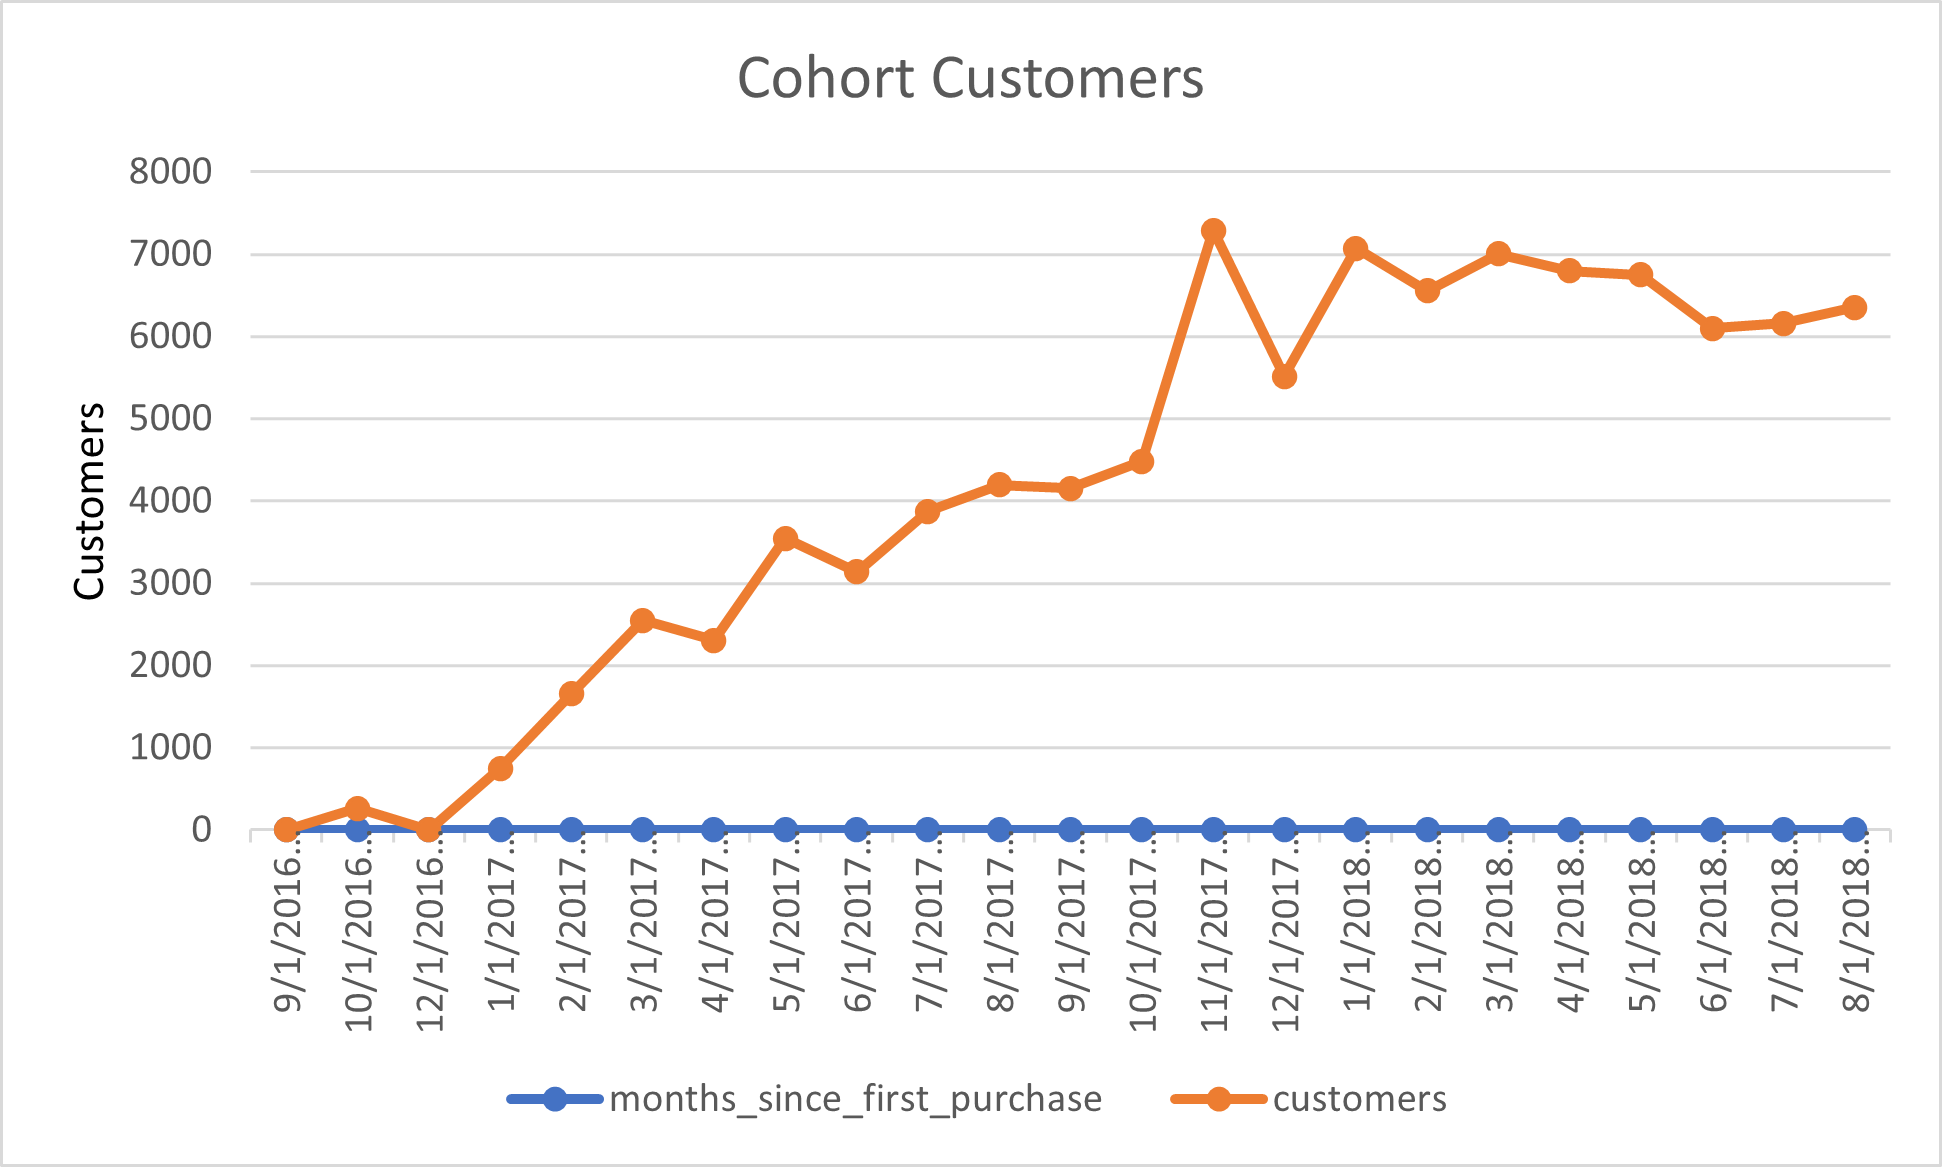

### Key Insight

The number of new customers joining the platform increases significantly from early 2017 onward.

Customer acquisition grows steadily throughout 2017 and peaks around late 2017 and early 2018, indicating rapid expansion of the marketplace during this period.

After the peak, customer acquisition stabilizes, suggesting that the platform reached a more mature growth stage while maintaining a consistent inflow of new customers.


## Summary of SQL Insights

Key findings from the SQL-based analysis include:

* **Revenue Growth:**
  Revenue increased significantly throughout **2017**, indicating strong **marketplace expansion and rising customer activity**.

* **Delivery Performance:**
  The vast majority of orders are **delivered on time**, showing strong operational performance. However, **delivery delays negatively impact customer satisfaction**, making logistics efficiency critical.

* **Customer Retention:**
  Most customers make **only one purchase**, while a much smaller proportion return for additional orders. This suggests an opportunity to improve **customer retention and loyalty strategies**.

* **Customer Acquisition:**
  The number of new customers joining the platform **increased steadily during 2017**, showing rapid **platform adoption and growth**.


### Business Implications

* Focus on **improving customer retention** to increase **customer lifetime value**.
* Maintain strong **delivery performance** to protect **customer satisfaction and reviews**.
* Continue strategies that support **customer acquisition and platform growth**.

